# Previsão de Decisões Judiciais — Pipeline TF-IDF

Este notebook usa **vetorização TF-IDF** — a mesma técnica do artigo original — para alimentar modelos de classificação.

> Lage-Freitas et al. (2022). *Predicting Brazilian Court Decisions*. PeerJ Computer Science.

**Modelos treinados neste arquivo:**
- Regressão Logística + TF-IDF *(contribuição deste trabalho — não testada no artigo)*
- SVM, XGBoost, Random Forest, Naive Bayes *(replicação dos modelos clássicos do artigo, para referência)*

**Por que TF-IDF precisa de pré-processamento pesado:**
TF-IDF não entende contexto — ele só conta a frequência de palavras. Por isso, antes de vetorizar, o texto passa por: lowercase, remoção de acentos, remoção de stopwords e stemming (RSLP). Isso reduz o vocabulário e concentra o sinal estatístico nas palavras que realmente diferenciam as classes.

Este pré-processamento é **idêntico ao artigo original** — só os modelos de classificação mudam.

## 0. Instalação de dependências

In [3]:
!pip install datasets nltk scikit-learn xgboost pandas numpy unidecode seaborn matplotlib --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import unidecode
import re
import time

import nltk
nltk.download('rslp', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

print('Imports concluídos.')

c:\Users\flavi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports concluídos.


## 2. Carregamento dos dados
> Idêntico ao artigo original

In [5]:
# ── Carregamento do dataset — idêntico ao artigo original ───────────────────
print('Carregando dataset...')
raw = load_dataset('joelniklaus/brazilian_court_decisions', 'default')

df_train = raw['train'].to_pandas()
df_val   = raw['validation'].to_pandas()
df_test  = raw['test'].to_pandas()

data = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'data.shape={data.shape}  full data set')

Carregando dataset...


data.shape=(4043, 10)  full data set


## 3. Limpeza dos dados
> Idêntica ao artigo original

In [6]:
# ── Limpeza idêntica ao artigo original (Lage-Freitas et al., 2022) ─────────

data = data.dropna(subset=['decision_description'])
data = data.dropna(subset=['judgment_label'])
print(f'data.shape={data.shape}  dropna')

data = data.drop_duplicates(subset=['process_number'])
print(f'data.shape={data.shape}  removed duplicated samples by process_number')

data = data.drop_duplicates(subset=['decision_description'])
print(f'data.shape={data.shape}  removed duplicated samples by decision_description')

data = data.query('judgment_label != "conflito-competencia"')
print(f'data.shape={data.shape}  removed conflito-competencia')
data = data.query('judgment_label != "prejudicada"')
print(f'data.shape={data.shape}  removed prejudicada')
data = data.query('judgment_label != "not-cognized"')
print(f'data.shape={data.shape}  removed not-cognized')

data_no      = data.query('judgment_label == "no"')
data_yes     = data.query('judgment_label == "yes"')
data_partial = data.query('judgment_label == "partial"')

data_merged = data_no.merge(data_yes, how='outer')
data = data_merged.merge(data_partial, how='outer')
print(f'data.shape={data.shape}  merged yes/no/partial')

indexNames = data[
    (data['decision_description'] == str(-1)) |
    (data['decision_description'] == str(-2)) |
    (data['judgment_label']       == str(-1)) |
    (data['judgment_label']       == str(-2))
].index
data.drop(indexNames, inplace=True)
print(f'data.shape={data.shape}  removed -1 and -2 values')

data = data.reset_index(drop=True)

print('\nDistribuição final dos rótulos:')
print(data['judgment_label'].value_counts())

data.shape=(4043, 10)  dropna
data.shape=(4043, 10)  removed duplicated samples by process_number
data.shape=(4043, 10)  removed duplicated samples by decision_description
data.shape=(4043, 10)  removed conflito-competencia
data.shape=(4043, 10)  removed prejudicada
data.shape=(4043, 10)  removed not-cognized
data.shape=(4043, 10)  merged yes/no/partial
data.shape=(4043, 10)  removed -1 and -2 values

Distribuição final dos rótulos:
judgment_label
no         2415
partial     866
yes         762
Name: count, dtype: int64


## 4. Pré-processamento de texto para TF-IDF
> **Esta etapa é específica do pipeline TF-IDF.** Stemming e remoção de stopwords são necessários aqui porque o TF-IDF não entende contexto — ele depende de contagem de palavras exatas. No notebook de Transformers, esta etapa é deliberadamente diferente.

In [7]:
stop_words_pt = set(stopwords.words('portuguese'))
stemmer       = RSLPStemmer()

def preprocessar_tfidf(texto):
    """Pré-processamento pesado, adequado para TF-IDF:
    lowercase -> remove acentos -> remove pontuação -> remove stopwords -> stemming
    """
    if not isinstance(texto, str):
        return ''
    texto = unidecode.unidecode(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    tokens = texto.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words_pt and len(t) > 2]
    return ' '.join(tokens)

print('Aplicando pré-processamento (pode levar alguns minutos)...')
data['texto_tfidf'] = data['decision_description'].apply(preprocessar_tfidf)
print('Concluído.')

print('\nExemplo:')
print('ORIGINAL:   ', data['decision_description'].iloc[0][:160])
print('PROCESSADO: ', data['texto_tfidf'].iloc[0][:160])

Aplicando pré-processamento (pode levar alguns minutos)...
Concluído.

Exemplo:
ORIGINAL:    APELAÇÃO CRIMINAL. PENAL. PROCESSO PENAL. TRÁFICO. DOSIMETRIA. QUANTIDADE. CIRCUNSTÂNCIA REVALORADA. ARTIGO 42 DA LEI N 11343/06. RECURSO CONHECIDO E PROVIDO. P
PROCESSADO:  apelaca crim penal process penal traf dosimetr quant circunstanc revalor artig lei 11343 recurs conhec prov pen reduz consider apreend 55g cinquent cinc gram ca


In [8]:
# Codificação dos rótulos
le = preprocessing.LabelEncoder()
data['label_encoded'] = le.fit_transform(data['judgment_label'])
labels = le.classes_

print('Mapeamento de rótulos:')
for i, cls in enumerate(labels):
    print(f'  {i} -> {cls}')

y = data['label_encoded'].values

Mapeamento de rótulos:
  0 -> no
  1 -> partial
  2 -> yes


## 5. Vetorização TF-IDF
> A única etapa de "representação numérica" deste notebook

In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_tfidf = tfidf.fit_transform(data['texto_tfidf'].values)
print(f'Matriz TF-IDF: {X_tfidf.shape}')
print(f'Vocabulário:   {len(tfidf.vocabulary_)} termos')

Matriz TF-IDF: (4043, 10000)
Vocabulário:   10000 termos


## 6. Divisão treino / teste
> Mesma seed (random_state=42) usada no notebook de Transformers, para garantir comparabilidade

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Treino: 3234 amostras
Teste:  809 amostras


## 7. Função de avaliação

In [11]:
# ── Função de avaliação — usada para todos os modelos deste notebook ────────
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, classification_report, confusion_matrix)

resultados      = {}   # nome_modelo -> dict de métricas agregadas
preds_por_modelo = {}  # nome_modelo -> y_pred (para matriz de confusão depois)

def avaliar_modelo(nome, y_true, y_pred, tempo_treino=None):
    """Calcula métricas completas e guarda para comparação posterior."""
    f1_macro   = f1_score(y_true, y_pred, average='macro')
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    acc        = accuracy_score(y_true, y_pred)
    f1_por_classe = f1_score(y_true, y_pred, average=None, zero_division=0)

    resultados[nome] = {
        'f1_macro': f1_macro,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'accuracy': acc,
        'tempo_treino_s': tempo_treino,
    }
    for i, classe in enumerate(labels):
        resultados[nome][f'f1_{classe}'] = f1_por_classe[i]

    preds_por_modelo[nome] = y_pred

    print(f'\n{"="*58}')
    print(f'  {nome}')
    print(f'{"="*58}')
    print(f'  F1-macro:        {f1_macro:.4f}')
    print(f'  Precision-macro: {prec_macro:.4f}')
    print(f'  Recall-macro:    {rec_macro:.4f}')
    print(f'  Acurácia:        {acc:.4f}')
    if tempo_treino is not None:
        print(f'  Tempo de treino: {tempo_treino:.1f}s')
    print()
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    return f1_macro

## 8. MODELO 1 — Regressão Logística + TF-IDF
> Contribuição deste trabalho. Não testado no artigo original.

In [12]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                          random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='f1_macro')
print(f'CV F1-macro (5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

lr.fit(X_train, y_train)
tempo_lr = time.time() - t0
y_pred_lr = lr.predict(X_test)

avaliar_modelo('Regressão Logística', y_test, y_pred_lr, tempo_lr)

CV F1-macro (5-fold): 0.6489 +/- 0.0229

  Regressão Logística
  F1-macro:        0.6506
  Precision-macro: 0.7325
  Recall-macro:    0.6170
  Acurácia:        0.7466
  Tempo de treino: 2.1s

              precision    recall  f1-score   support

          no       0.75      0.94      0.84       483
     partial       0.74      0.50      0.59       173
         yes       0.71      0.41      0.52       153

    accuracy                           0.75       809
   macro avg       0.73      0.62      0.65       809
weighted avg       0.74      0.75      0.73       809



0.6505673300664554

In [13]:
# Análise qualitativa — quais palavras mais pesam por classe
feature_names = tfidf.get_feature_names_out()
print('Top 8 palavras por classe (maior peso na Regressão Logística):\n')
for i, classe in enumerate(labels):
    top_idx = np.argsort(lr.coef_[i])[-8:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    print(f'  {classe.upper():10s}: {", ".join(top_words)}')

Top 8 palavras por classe (maior peso na Regressão Logística):

  NO        : mant, sentenc mant, nao acolh, manutenca, nao, ileg nao, conhec improv, improv
  PARTIAL   : parc, reduz, reduca, dosimetr, afast, astreint, conhec parc, circunstanc
  YES       : reform, sentenc reform, extinca, conhec prov, inversa, limin, anul, feit


## 9. Modelos de referência (replicação do artigo)
> SVM, XGBoost, Random Forest e Naive Bayes usam a mesma vetorização TF-IDF. Replicá-los aqui permite comparar diretamente com a Regressão Logística, dentro do mesmo pipeline.

In [14]:
t0 = time.time()
svm = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm.fit(X_train, y_train)
tempo_svm = time.time() - t0
y_pred_svm = svm.predict(X_test)
avaliar_modelo('SVM (referência artigo)', y_test, y_pred_svm, tempo_svm)


  SVM (referência artigo)
  F1-macro:        0.6979
  Precision-macro: 0.7276
  Recall-macro:    0.6784
  Acurácia:        0.7750
  Tempo de treino: 0.2s

              precision    recall  f1-score   support

          no       0.82      0.92      0.87       483
     partial       0.69      0.58      0.63       173
         yes       0.67      0.54      0.60       153

    accuracy                           0.78       809
   macro avg       0.73      0.68      0.70       809
weighted avg       0.76      0.78      0.77       809



0.6978623789668429

In [15]:
t0 = time.time()
xgb = XGBClassifier(n_estimators=200, max_depth=6, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
tempo_xgb = time.time() - t0
y_pred_xgb = xgb.predict(X_test)
avaliar_modelo('XGBoost (referência artigo)', y_test, y_pred_xgb, tempo_xgb)


  XGBoost (referência artigo)
  F1-macro:        0.7033
  Precision-macro: 0.7311
  Recall-macro:    0.6845
  Acurácia:        0.7775
  Tempo de treino: 70.1s

              precision    recall  f1-score   support

          no       0.82      0.92      0.87       483
     partial       0.69      0.57      0.63       173
         yes       0.68      0.56      0.61       153

    accuracy                           0.78       809
   macro avg       0.73      0.68      0.70       809
weighted avg       0.77      0.78      0.77       809



0.7032508442947146

In [16]:
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
tempo_rf = time.time() - t0
y_pred_rf = rf.predict(X_test)
avaliar_modelo('Random Forest (referência artigo)', y_test, y_pred_rf, tempo_rf)


  Random Forest (referência artigo)
  F1-macro:        0.5473
  Precision-macro: 0.7337
  Recall-macro:    0.5239
  Acurácia:        0.7021
  Tempo de treino: 1.0s

              precision    recall  f1-score   support

          no       0.69      0.97      0.81       483
     partial       0.75      0.42      0.54       173
         yes       0.76      0.18      0.29       153

    accuracy                           0.70       809
   macro avg       0.73      0.52      0.55       809
weighted avg       0.72      0.70      0.65       809



0.5473468741898885

In [17]:
t0 = time.time()
nb = GaussianNB()
nb.fit(X_train.toarray(), y_train)
tempo_nb = time.time() - t0
y_pred_nb = nb.predict(X_test.toarray())
avaliar_modelo('Naive Bayes (referência artigo)', y_test, y_pred_nb, tempo_nb)


  Naive Bayes (referência artigo)
  F1-macro:        0.5417
  Precision-macro: 0.5547
  Recall-macro:    0.5415
  Acurácia:        0.6341
  Tempo de treino: 0.8s

              precision    recall  f1-score   support

          no       0.74      0.77      0.75       483
     partial       0.47      0.55      0.50       173
         yes       0.46      0.31      0.37       153

    accuracy                           0.63       809
   macro avg       0.55      0.54      0.54       809
weighted avg       0.63      0.63      0.63       809



0.5417139092595482

## 10. Comparação e visualização dos resultados

In [18]:
# ── Montar DataFrame de comparação ───────────────────────────────────────────
import pandas as pd

df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('f1_macro', ascending=False)
df_resultados_fmt = df_resultados.copy()
for col in df_resultados_fmt.columns:
    if col != 'tempo_treino_s':
        df_resultados_fmt[col] = (df_resultados_fmt[col] * 100).round(2)

print('── TABELA RESUMO — Pipeline TF-IDF ──')
display(df_resultados_fmt)

── TABELA RESUMO — Pipeline TF-IDF ──


,f1_macro,precision_macro,recall_macro,accuracy,tempo_treino_s,f1_no,f1_partial,f1_yes
XGBoost (referência artigo),70.33,73.11,68.45,77.75,70.132747,86.89,62.66,61.43
SVM (referência artigo),69.79,72.76,67.84,77.50,0.198367,86.83,62.89,59.64
Regressão Logística,65.06,73.25,61.70,74.66,2.077161,83.79,59.31,52.07
Random Forest (referência artigo),54.73,73.37,52.39,70.21,0.962600,80.66,54.07,29.47
Naive Bayes (referência artigo),54.17,55.47,54.15,63.41,0.782727,75.25,50.40,36.86


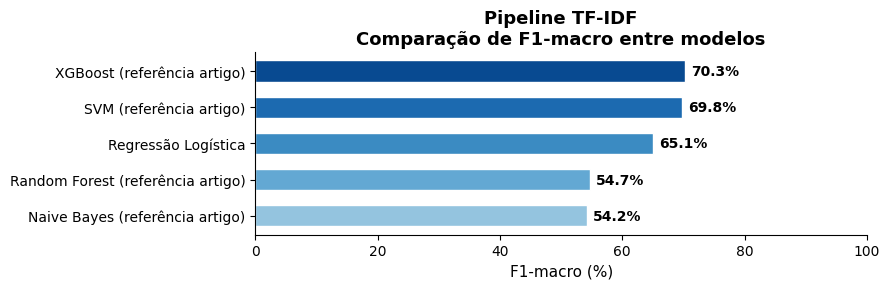

In [19]:
# ── Gráfico 1: F1-macro comparativo (barras horizontais) ────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, max(3, 0.6*len(df_resultados))))
modelos_ord = df_resultados.index.tolist()
valores     = (df_resultados['f1_macro'] * 100).tolist()

cores = plt.cm.Blues(np.linspace(0.9, 0.4, len(modelos_ord)))
bars = ax.barh(modelos_ord, valores, color=cores, edgecolor='white', height=0.6)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('F1-macro (%)', fontsize=11)
ax.set_title('Pipeline TF-IDF\nComparação de F1-macro entre modelos', fontsize=13, fontweight='bold')

for bar, val in zip(bars, valores):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold')

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('f1_macro_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

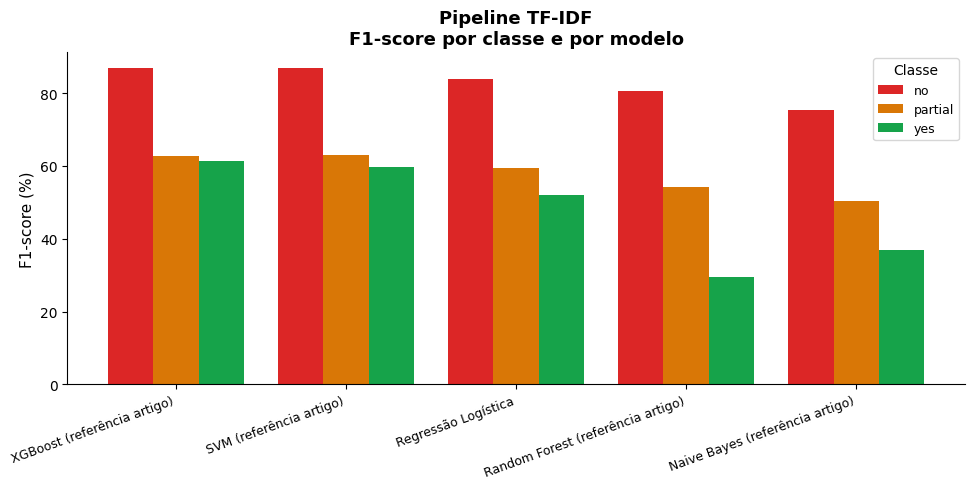

In [20]:
# ── Gráfico 2: F1 por classe (barras agrupadas) ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

n_modelos = len(modelos_ord)
n_classes = len(labels)
largura   = 0.8 / n_classes
x = np.arange(n_modelos)

cores_classe = {'yes': '#16A34A', 'partial': '#D97706', 'no': '#DC2626'}

for i, classe in enumerate(labels):
    valores_classe = [df_resultados.loc[m, f'f1_{classe}'] * 100 for m in modelos_ord]
    ax.bar(x + i*largura, valores_classe, largura,
           label=classe, color=cores_classe.get(classe, '#888888'))

ax.set_xticks(x + largura*(n_classes-1)/2)
ax.set_xticklabels(modelos_ord, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('F1-score (%)', fontsize=11)
ax.set_title('Pipeline TF-IDF\nF1-score por classe e por modelo', fontsize=13, fontweight='bold')
ax.legend(title='Classe', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('f1_por_classe_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

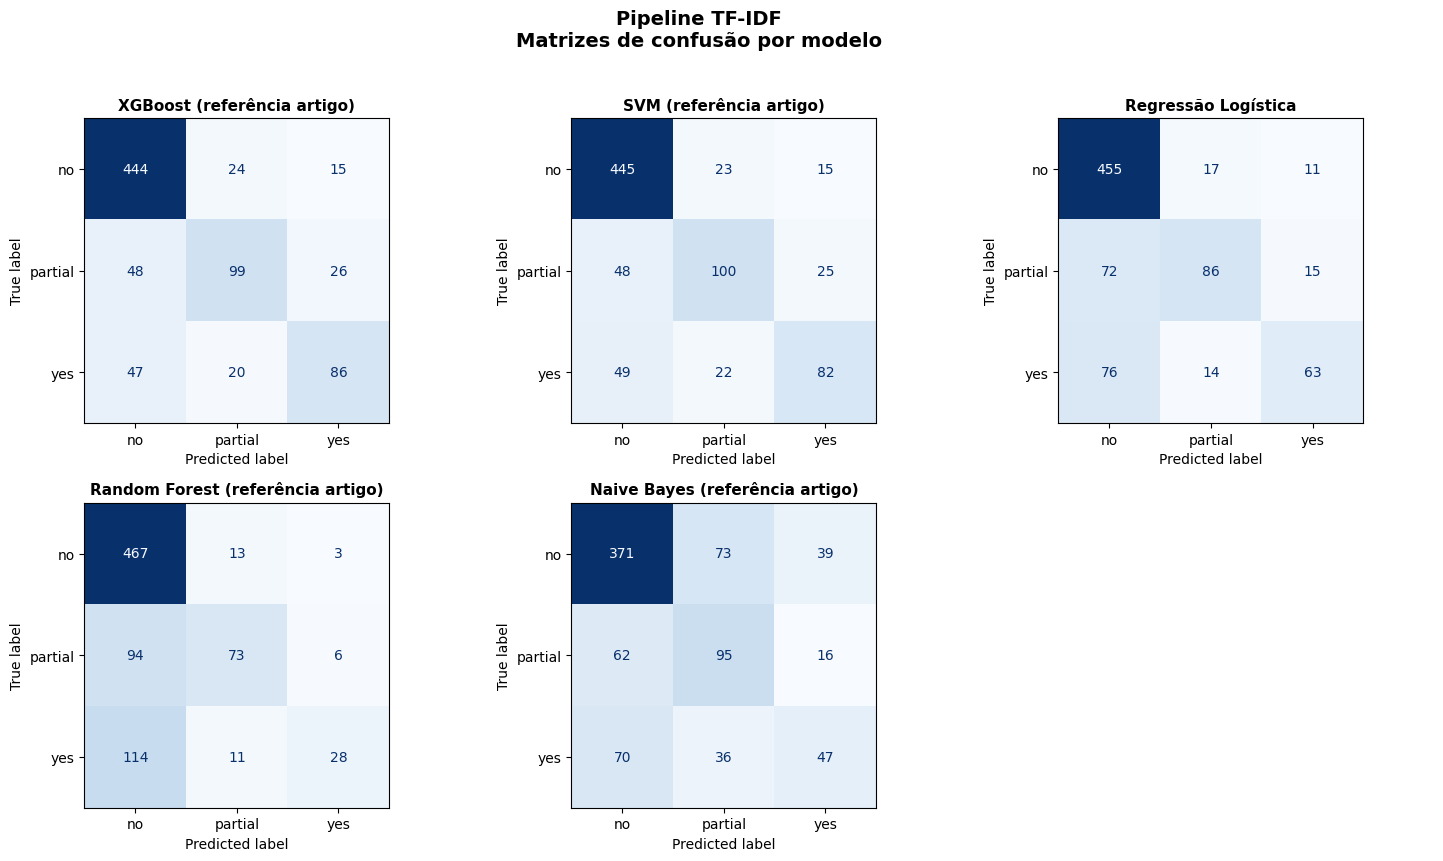

In [21]:
# ── Gráfico 3: Matrizes de confusão — grid com todos os modelos ─────────────
from sklearn.metrics import ConfusionMatrixDisplay

n = len(modelos_ord)
n_cols = min(3, n)
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.2*n_rows))
axes = np.array(axes).reshape(-1) if n > 1 else [axes]

for i, nome in enumerate(modelos_ord):
    y_pred_modelo = preds_por_modelo[nome]
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_modelo,
        display_labels=labels, cmap='Blues',
        ax=axes[i], colorbar=False
    )
    axes[i].set_title(nome, fontsize=11, fontweight='bold')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('Pipeline TF-IDF\nMatrizes de confusão por modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrizes_confusao_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

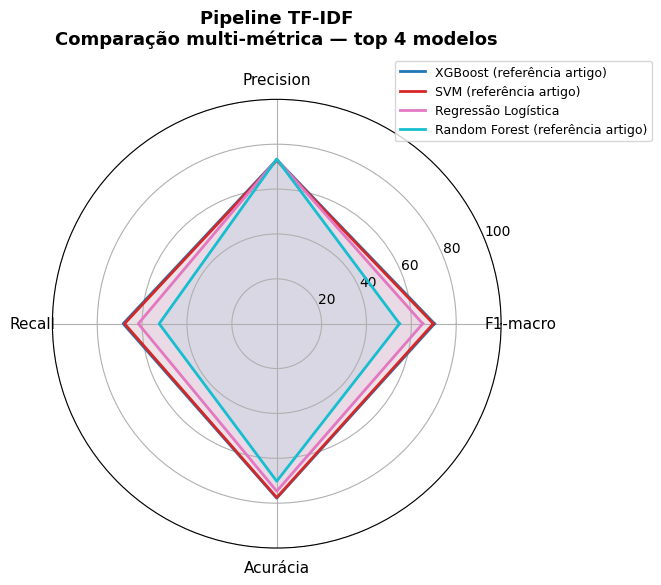

In [22]:
# ── Gráfico 4: Radar comparando 4 métricas-chave (top modelos) ──────────────
top_n = min(4, len(modelos_ord))
top_modelos = modelos_ord[:top_n]

metricas_radar = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy']
labels_radar   = ['F1-macro', 'Precision', 'Recall', 'Acurácia']

angles = np.linspace(0, 2*np.pi, len(metricas_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cores_radar = plt.cm.tab10(np.linspace(0, 1, top_n))

for idx, nome in enumerate(top_modelos):
    valores_radar = [df_resultados.loc[nome, m] * 100 for m in metricas_radar]
    valores_radar += valores_radar[:1]
    ax.plot(angles, valores_radar, linewidth=2, label=nome, color=cores_radar[idx])
    ax.fill(angles, valores_radar, alpha=0.08, color=cores_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Pipeline TF-IDF\nComparação multi-métrica — top {} modelos'.format(top_n),
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('radar_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Salvar resultados para comparação cruzada entre notebooks ────────────────
df_resultados.to_csv('results_tfidf.csv', index=True, index_label='modelo')
print(f'Resultados salvos em: results_tfidf.csv')
print(f'\nMelhor modelo deste notebook: {modelos_ord[0]}  (F1-macro = {valores[0]:.1f}%)')

Resultados salvos em: results_tfidf.csv

Melhor modelo deste notebook: XGBoost (referência artigo)  (F1-macro = 70.3%)


## 11. Conclusão

Este notebook isolou o efeito da **vetorização TF-IDF** combinada com 5 classificadores diferentes. A Regressão Logística — não testada no artigo original — pode ser comparada diretamente aos modelos clássicos replicados (SVM, XGBoost, Random Forest, Naive Bayes).

Para comparar estes resultados com os modelos baseados em Transformers, execute também o notebook `transformers_pipeline_court_decisions.ipynb` e use o arquivo `results_tfidf.csv` gerado aqui.